In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import nibabel as nib

In [1]:
import os
from collections import defaultdict

test_path = '/data/falcetta/A2V_experiments/IXI_preprocessed/preprocess_IXI/test'

# Dictionary to store slice counts
patient_slices = defaultdict()

# Extract patient IDs and count slices
for filename in os.listdir(test_path):
    if filename.endswith('.npy'):
        # Extract patient ID (first 20 characters)
        patient_id = filename[:20]
        # Count slices for each patient
        if patient_id in patient_slices:
            patient_slices[patient_id] += 1
        else:
            patient_slices[patient_id] = 1

# Print results
for patient_id, slice_count in patient_slices.items():
    print(f"Patient {patient_id}: {slice_count} slices")

print(f"\nTotal number of patients: {len(patient_slices)}")

Patient IXI022-Guys-0701-MRA: 100 slices
Patient IXI026-Guys-0696-MRA: 100 slices
Patient IXI027-Guys-0710-MRA: 100 slices
Patient IXI029-Guys-0829-MRA: 100 slices
Patient IXI030-Guys-0708-MRA: 100 slices
Patient IXI031-Guys-0797-MRA: 100 slices
Patient IXI033-HH-1259-MRA_s: 100 slices
Patient IXI034-HH-1260-MRA_s: 100 slices
Patient IXI035-IOP-0873-MRA_: 92 slices
Patient IXI036-Guys-0736-MRA: 100 slices
Patient IXI037-Guys-0704-MRA: 100 slices
Patient IXI038-Guys-0729-MRA: 100 slices
Patient IXI039-HH-1261-MRA_s: 100 slices
Patient IXI041-Guys-0706-MRA: 100 slices
Patient IXI068-Guys-0756-MRA: 100 slices
Patient IXI050-Guys-0711-MRA: 100 slices
Patient IXI066-Guys-0731-MRA: 100 slices
Patient IXI049-HH-1358-MRA_s: 100 slices
Patient IXI048-HH-1326-MRA_s: 100 slices
Patient IXI046-Guys-0824-MRA: 100 slices
Patient IXI045-Guys-0713-MRA: 100 slices
Patient IXI078-Guys-0751-MRA: 100 slices
Patient IXI053-Guys-0727-MRA: 100 slices
Patient IXI054-Guys-0707-MRA: 100 slices
Patient IXI052-HH

In [82]:
def img_path_to_brain_path(img_path):
    return img_path.replace("imagesTr", "joined_masks_ct_whole").replace("_0000.nii.gz", "_brain_join_mask.nii.gz")
def img_path_to_vessel_path(img_path):
    return img_path.replace("imagesTr", "bin_labelsTr").replace("_0000.nii.gz", ".nii.gz")

# IF WE WANT TO DO EXPERIMENTS WITH COMPLETE VESSEL MASKS
def img_path_to_vessel_path_complete(img_path):
    vessel_path = img_path.replace("imagesTr", "bin_labelsTr").replace("_0000.nii.gz", "_COMPLETE_new.nii.gz")
    return vessel_path

def img_name_to_pred_name(img_name):
    return img_name.replace(".nii.gz", "_pred.nii.gz")
def img_name_to_inter_name(img_name):
    return img_name.replace(".nii.gz", "_inter.nii.gz")
def img_name_to_intra_name(img_name):
    return img_name.replace(".nii.gz", "_intra.nii.gz")
def img_name_to_trans_name(img_name):
    return img_name.replace(".nii.gz", "_trans.nii.gz")

In [83]:
def reorient_to_target_improved(source_img, target_img):
    """
    Reorient a source image to match the orientation of a target image,
    with explicit handling of flips along each axis.
    
    Parameters:
    -----------
    source_img : nibabel.Nifti1Image
        The image to be reoriented
    target_img : nibabel.Nifti1Image
        The target image whose orientation we want to match
    
    Returns:
    --------
    nibabel.Nifti1Image
        Correctly reoriented image
    """
    # Get current orientations
    source_orientation = nib.aff2axcodes(source_img.affine)
    target_orientation = nib.aff2axcodes(target_img.affine)
    
    # Get the data
    data = source_img.get_fdata()
    
    # First flip left-right (AP axis)
    #data = np.flip(data, axis=0)
    
    # If still needed, try other axes
    data = np.flip(data, axis=1)  # Uncomment if needed
    # data = np.flip(data, axis=2)  # Uncomment if needed
    
    # Create new affine that matches target orientation
    new_affine = target_img.affine.copy()
    
    # Adjust affine for voxel size differences
    src_zooms = source_img.header.get_zooms()[:3]
    target_zooms = target_img.header.get_zooms()[:3]
    
    for i in range(3):
        new_affine[i, i] = new_affine[i, i] * (src_zooms[i] / target_zooms[i])
    
    # Create new image
    reoriented_img = nib.Nifti1Image(data, new_affine)
    
    return reoriented_img

In [84]:
from scipy.ndimage import center_of_mass
from scipy.stats import pearsonr

def determine_best_flip(source_data, target_data):
    """
    Determine which axis flip produces the most similar image to the target
    by comparing image similarities.
    
    Parameters:
    -----------
    source_data : numpy.ndarray
        The source image data to be flipped
    target_data : numpy.ndarray
        The target image data to match
        
    Returns:
    --------
    tuple
        (best_axis, best_correlation)
    """
    best_correlation = float('-inf')
    best_axis = None
    
    # Try flipping along each axis
    for axis in range(3):
        # Flip the data
        flipped_data = np.flip(source_data, axis=axis)
        
        # Flatten arrays for correlation
        flat_target = target_data.flatten()
        flat_flipped = flipped_data.flatten()
        
        # Calculate correlation
        correlation = pearsonr(flat_target, flat_flipped)[0]
        
        if correlation > best_correlation:
            best_correlation = correlation
            best_axis = axis
    
    return best_axis, best_correlation

def reorient_with_auto_flip(source_img, target_img, new_affine=False):
    """
    Reorient a source image to match the orientation of a target image
    with automated flip detection.
    
    Parameters:
    -----------
    source_img : nibabel.Nifti1Image
        The image to be reoriented
    target_img : nibabel.Nifti1Image
        The target image whose orientation we want to match
    
    Returns:
    --------
    nibabel.Nifti1Image
        Correctly reoriented image
    """
    # Get the data
    source_data = source_img.get_fdata()
    target_data = target_img.get_fdata()
    
    # Find best flip
    best_axis, correlation = determine_best_flip(source_data, target_data)
    print(f"Best flip axis: {best_axis} (correlation: {correlation:.3f})")
    
    # Apply the flip
    if best_axis is not None:
        data = np.flip(source_data, axis=best_axis)
    else:
        data = source_data
    
    if new_affine:
        # Create new image with target affine
        new_affine = target_img.affine.copy()
        
        # Adjust affine for voxel size differences
        src_zooms = source_img.header.get_zooms()[:3]
        target_zooms = target_img.header.get_zooms()[:3]
        
        for i in range(3):
            new_affine[i, i] = new_affine[i, i] * (src_zooms[i] / target_zooms[i])
        
        # Create new image
        reoriented_img = nib.Nifti1Image(data, new_affine)
    else:
        print("Using source affine")
        print(f"spacing source: {source_img.header.get_zooms()}")
        reoriented_img = nib.Nifti1Image(data, source_img.affine)
        
    return reoriented_img


In [85]:
from scipy.ndimage import zoom

def match_spacing(source_img, target_img, is_mask=True):
    """
    Resample source image to match the spacing of target image.
    
    Parameters:
    -----------
    source_img : nibabel.Nifti1Image
        The image to be resampled
    target_img : nibabel.Nifti1Image
        The target image whose spacing we want to match
    is_mask : bool
        Whether the source image is a binary mask
    
    Returns:
    --------
    nibabel.Nifti1Image
        Resampled image with matched spacing
    """
    # Get spacings
    source_spacing = source_img.header.get_zooms()[:3]  # Get X, Y, Z spacing
    target_spacing = target_img.header.get_zooms()[:3]
    
    # Calculate zoom factors
    zoom_factors = [t/s for t, s in zip(target_spacing, source_spacing)]
    
    # Get source data
    source_data = source_img.get_fdata()
    
    # Resample
    if is_mask:
        # Use nearest neighbor interpolation for masks
        resampled_data = zoom(source_data, zoom_factors, order=0)
    else:
        # Use linear interpolation for regular images
        resampled_data = zoom(source_data, zoom_factors, order=1)
    
    # Create new affine matrix
    new_affine = source_img.affine.copy()
    # Update spacing in affine matrix
    for i in range(3):
        new_affine[i, i] = new_affine[i, i] * zoom_factors[i]
    
    # Create new image
    resampled_img = nib.Nifti1Image(resampled_data, new_affine)
    
    return resampled_img






# Save if needed
# nib.save(resampled_trs, 'resampled_transformed_image.nii.gz')
# nib.save(resampled_pred, 'resampled_prediction.nii.gz')

In [86]:
# Function to update affine while preserving orthonormality
def update_affine_with_spacing(image, target_spacing):
    # Get the direction matrix (3x3 rotation matrix) from the image
    current_spacing = image.header.get_zooms()[:3]
    direction = image.affine[:3, :3] / np.array(current_spacing)[:, None]
    
    # Create new affine with original direction and new spacing
    new_affine = image.affine.copy()
    new_affine[:3, :3] = direction * np.array(target_spacing)[:, None]  # Apply spacing while preserving direction
    return new_affine

Missing /data/falcetta/A2V_experiments/OUTPUT_phase2/TopCow_INFERENCE/topcow_ct_whole_001_0000_pred.nii.gz
Missing /data/falcetta/A2V_experiments/OUTPUT_phase2/TopCow_INFERENCE/topcow_ct_whole_002_0000_pred.nii.gz
Missing /data/falcetta/A2V_experiments/OUTPUT_phase2/TopCow_INFERENCE/topcow_ct_whole_003_0000_pred.nii.gz

Processing topcow_ct_whole_004_0000.nii.gz
Found IMG,TRANS,INTER,INTRA, PRED
Original image shape: (351, 431, 224)
Transformed image shape: (351, 431, 224)
Prediction shape: (351, 431, 224)
Original image orientation: ('L', 'P', 'S')
Transformed image orientation: ('R', 'A', 'S')
Prediction orientation: ('R', 'A', 'S')
Original image spacing: (0.40625, 0.40625, 0.7000122)
Transformed image spacing: (1.0, 1.0, 1.0)
Prediction spacing: (1.0, 1.0, 1.0)
Best flip axis: 1 (correlation: 0.575)
Using source affine
spacing source: (1.0, 1.0, 1.0)
Best flip axis: 1 (correlation: 0.301)
Using source affine
spacing source: (1.0, 1.0, 1.0)
Best flip axis: 1 (correlation: 0.301)
Usi

/tmp/ipykernel_2528655/182409803.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1, 3, figsize=(20, 10))


Best flip axis: 1 (correlation: 0.633)
Using source affine
spacing source: (1.0, 1.0, 1.0)
Best flip axis: 1 (correlation: 0.229)
Using source affine
spacing source: (1.0, 1.0, 1.0)
Best flip axis: 1 (correlation: 0.229)
Using source affine
spacing source: (1.0, 1.0, 1.0)
Best flip axis: 1 (correlation: 0.229)
Using source affine
spacing source: (1.0, 1.0, 1.0)
Original image orientation: ('L', 'P', 'S')
Reoriented image orientation: ('R', 'A', 'S')
Reoriented prediction orientation: ('R', 'A', 'S')
Original image shape: (341, 376, 202)
Resampled transformed shape: (341, 376, 202)
Resampled prediction shape: (341, 376, 202)
Unique values in prediction: [0. 1. 2.]
Unique values in prediction: [0. 1.]
 Saving reoriented images to /data/falcetta/A2V_experiments/OUTPUT_phase2/TopCow_INFERENCE_oriented

Processing topcow_ct_whole_058_0000.nii.gz
Found IMG,TRANS,INTER,INTRA, PRED
Original image shape: (391, 467, 209)
Transformed image shape: (391, 467, 209)
Prediction shape: (391, 467, 209)


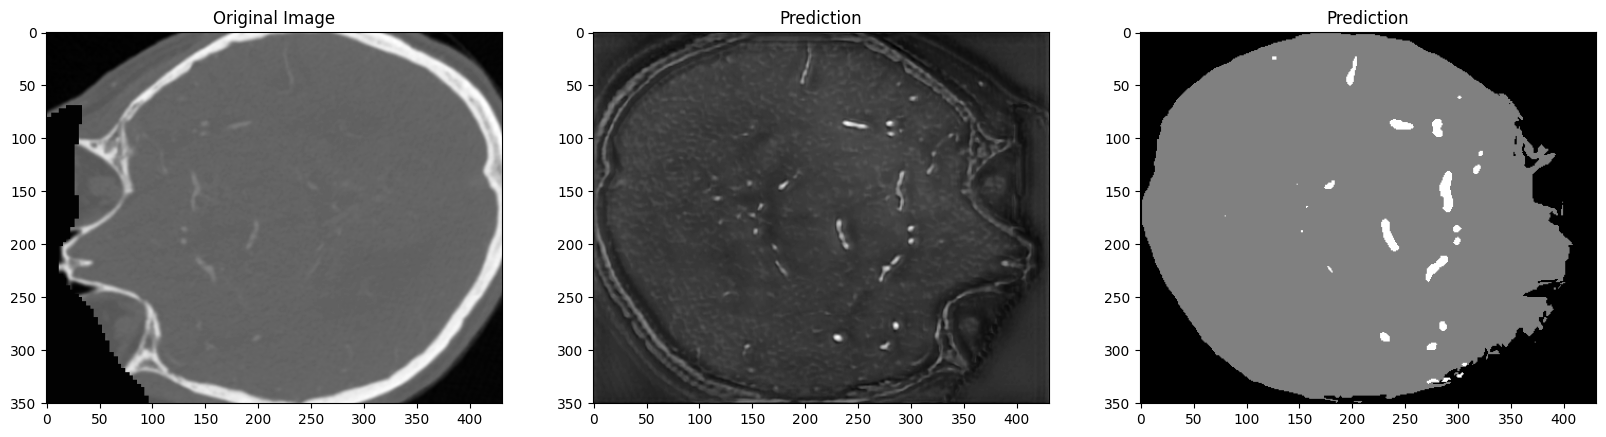

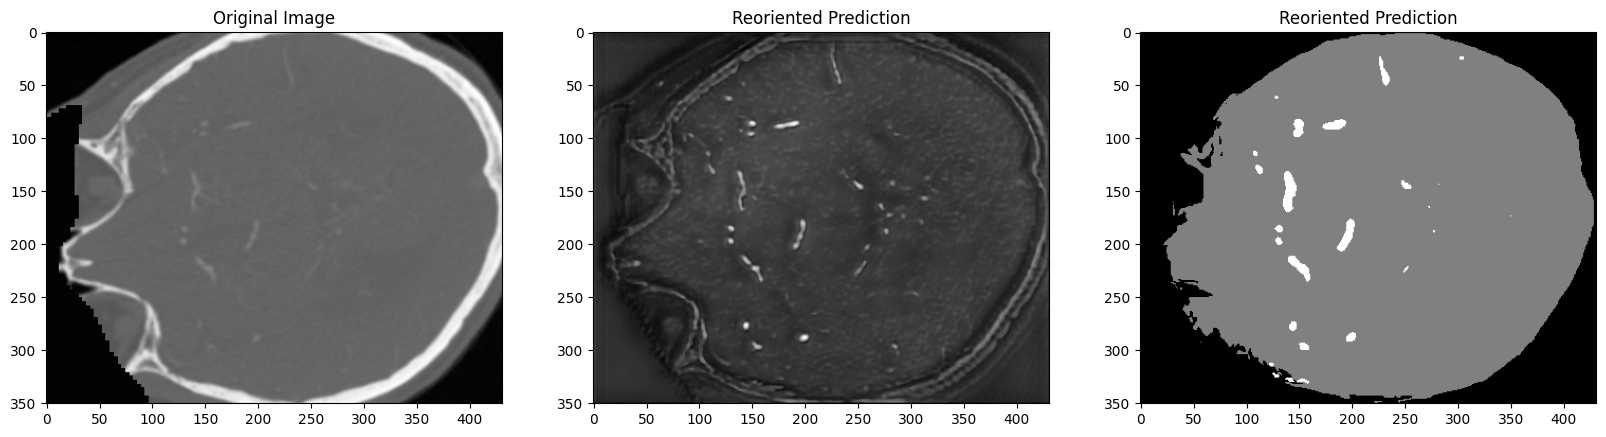

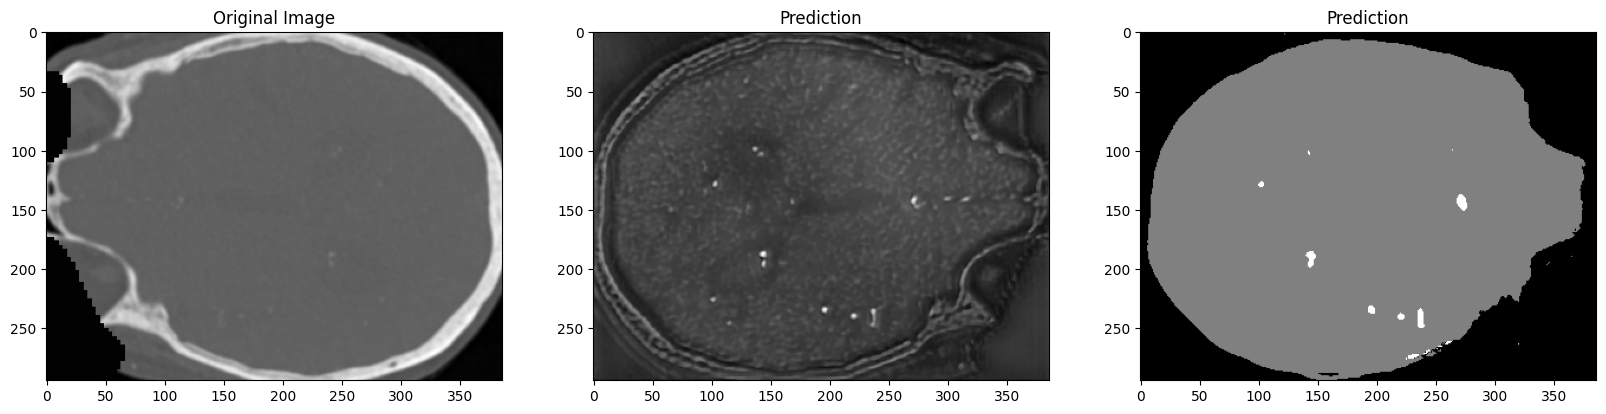

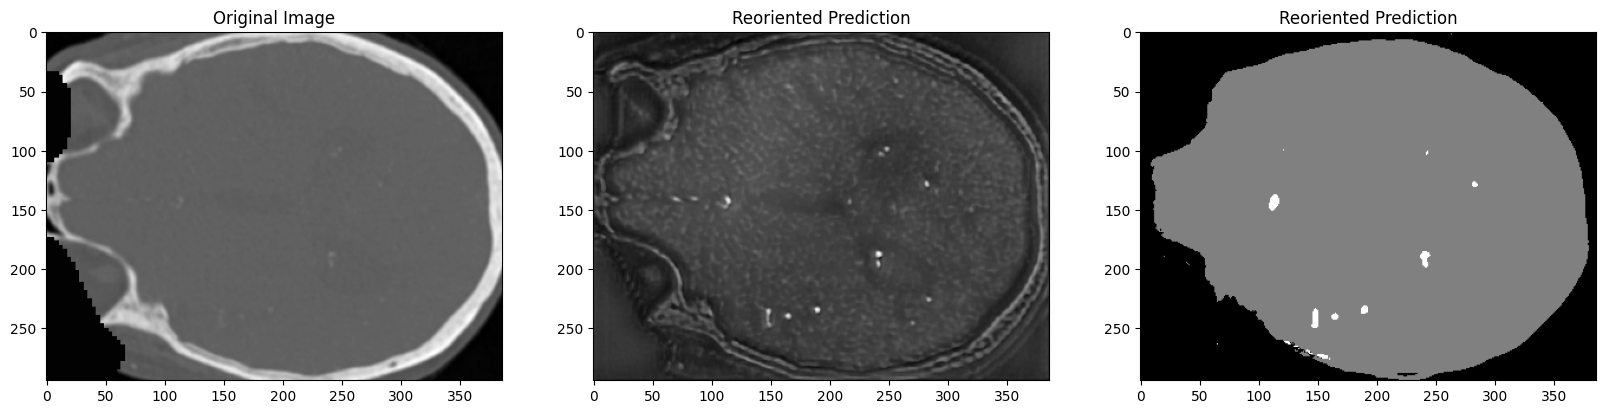

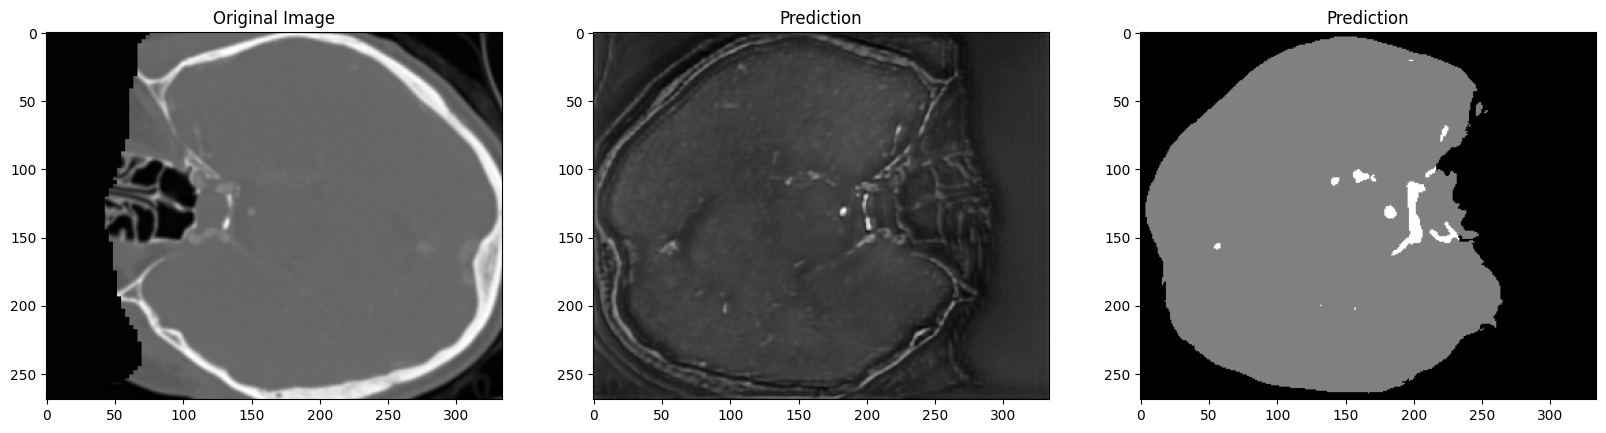

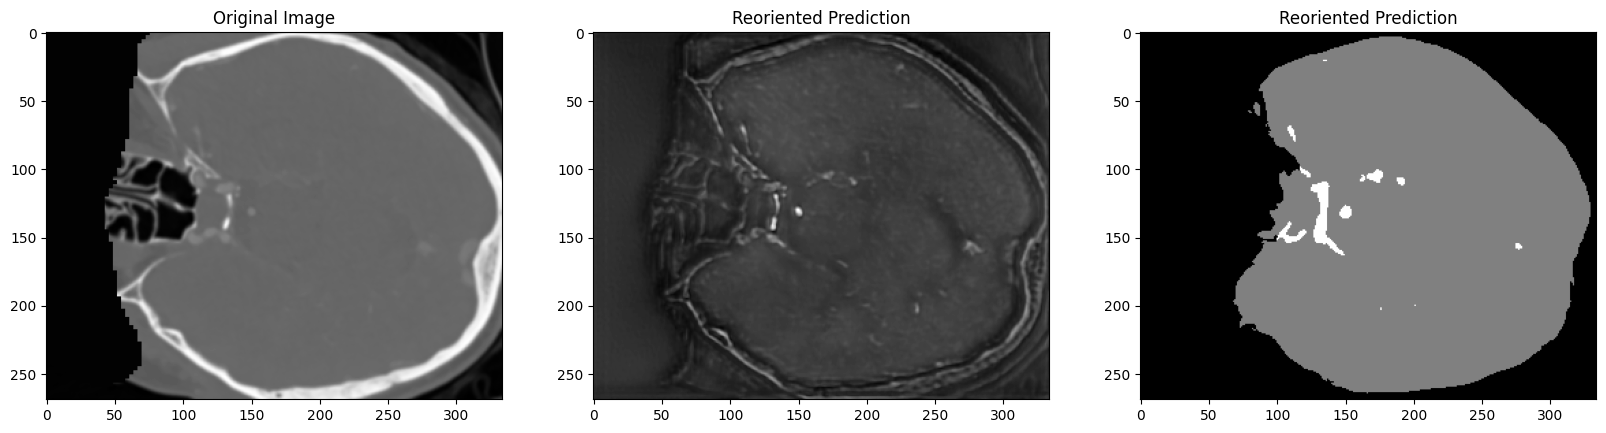

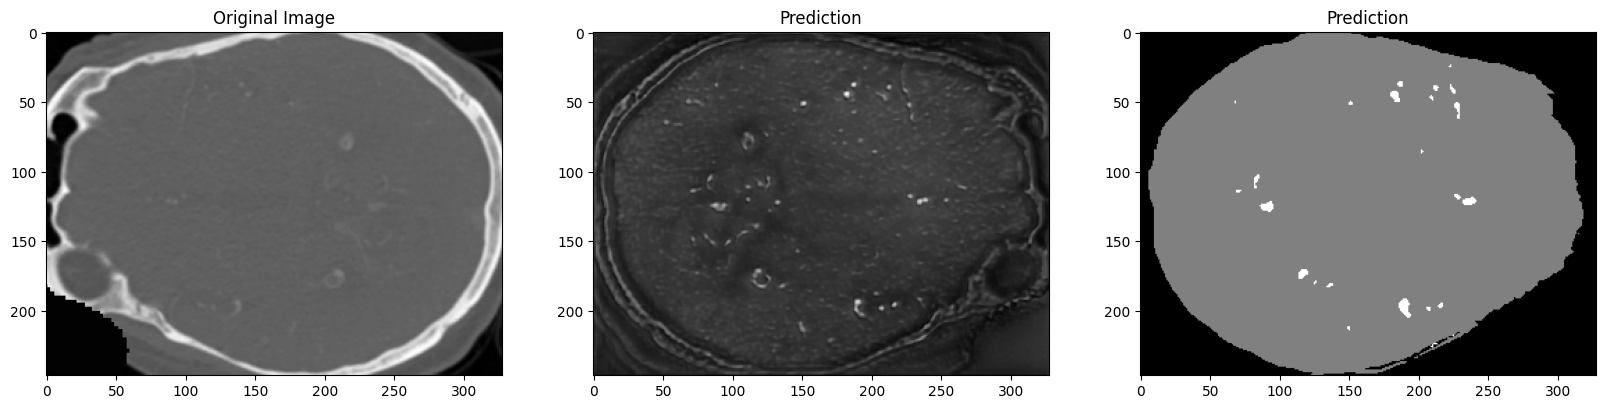

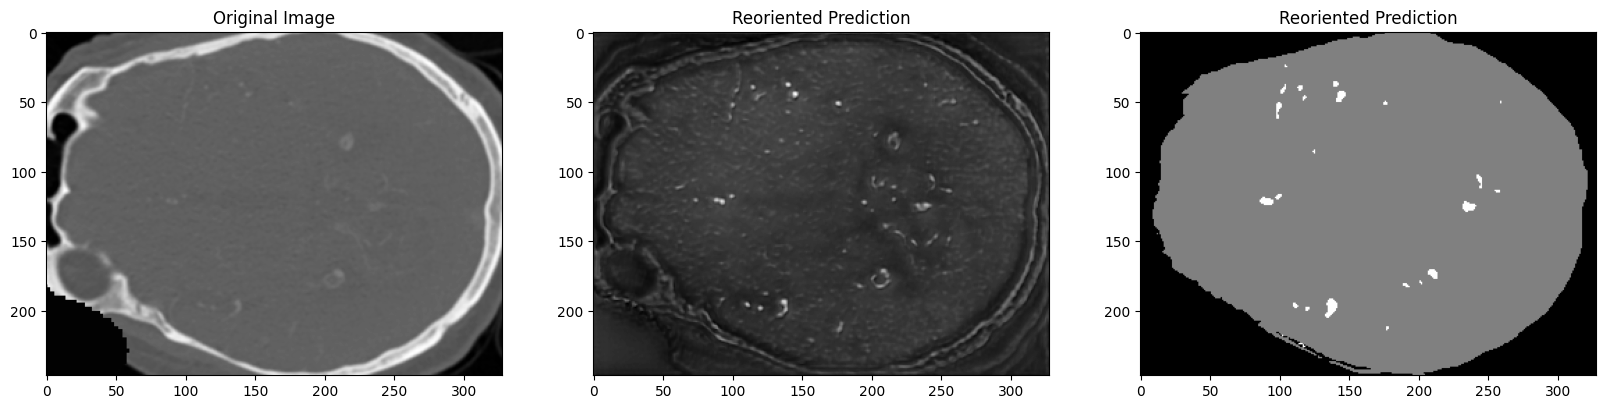

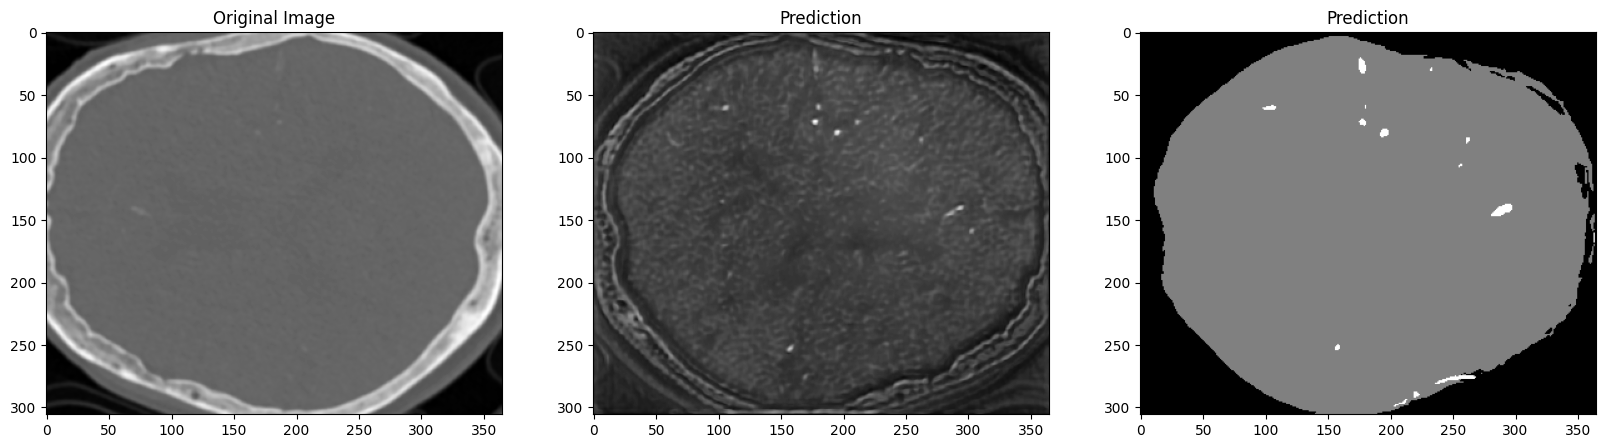

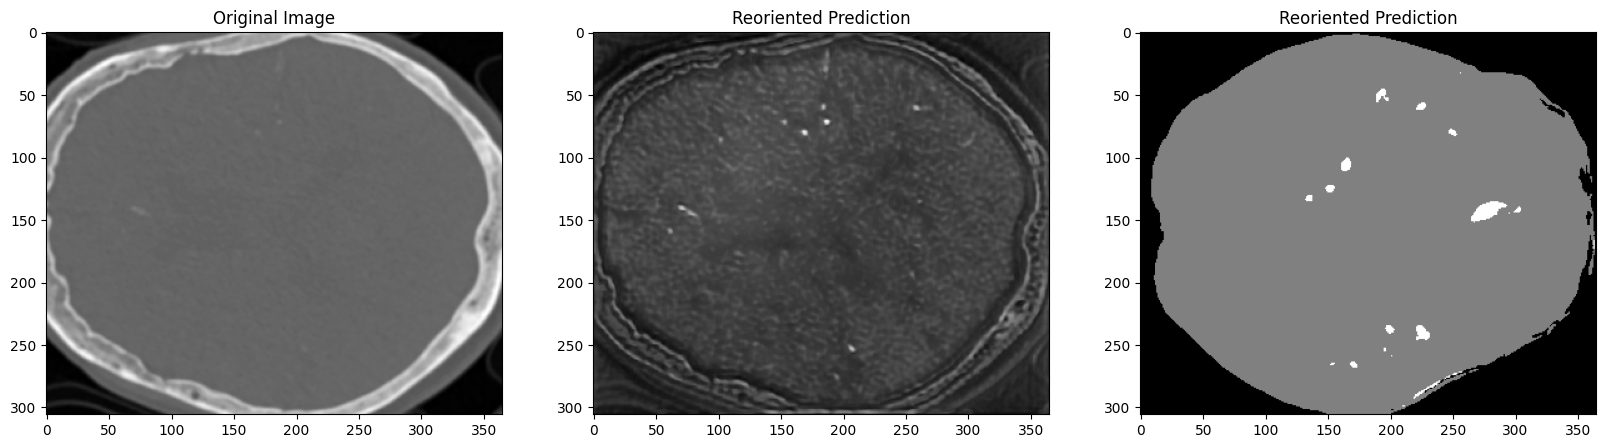

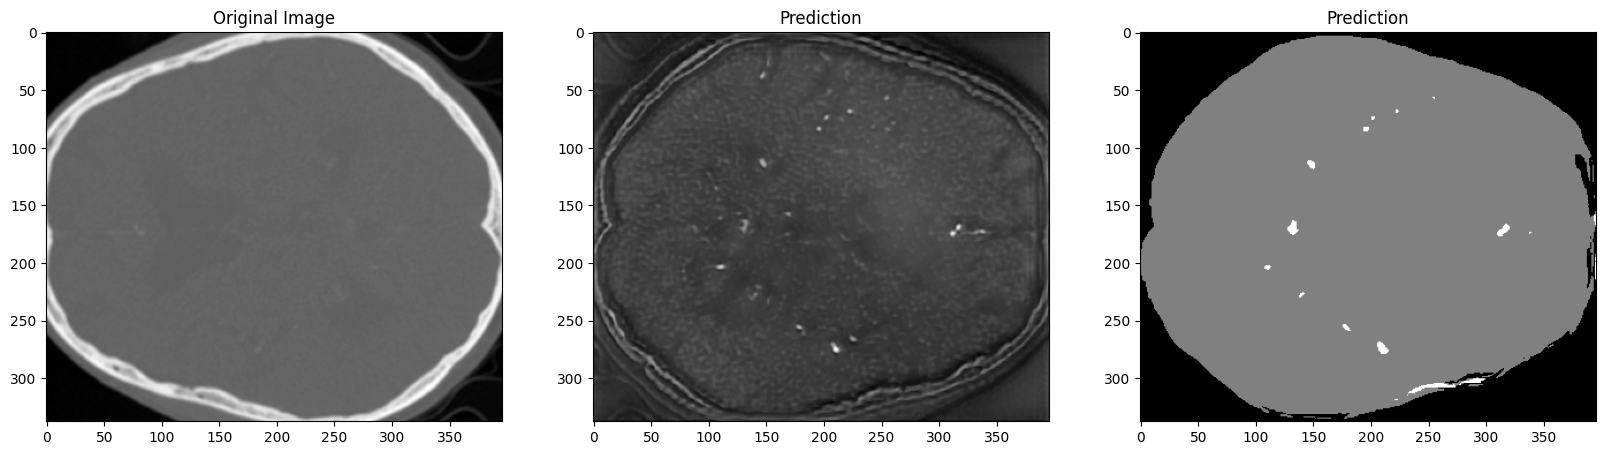

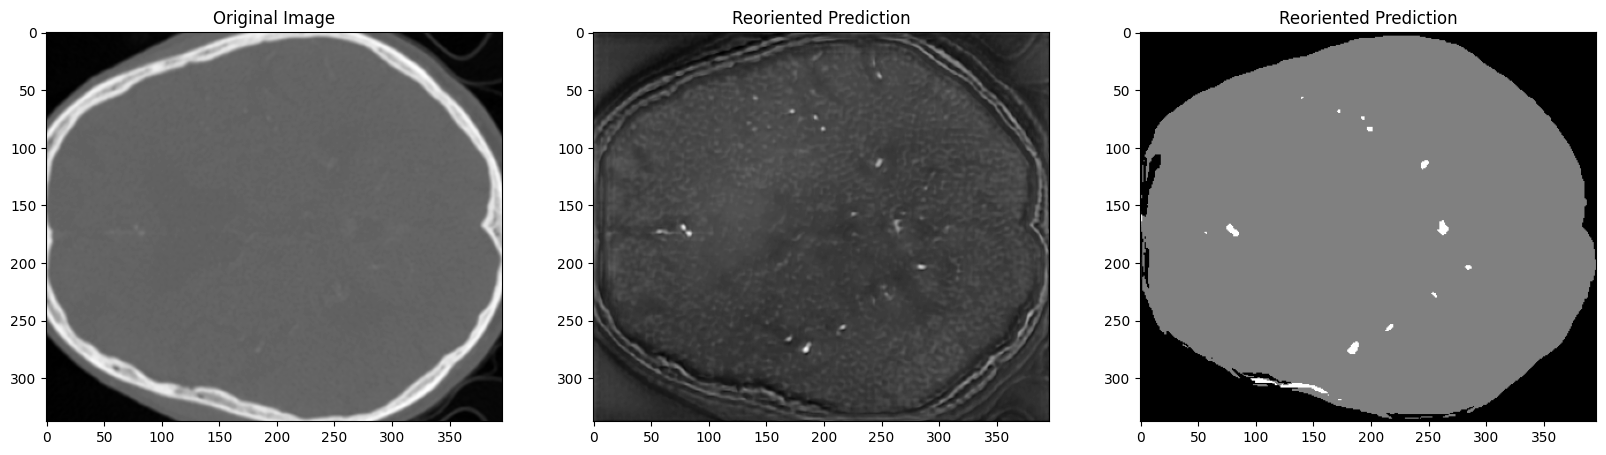

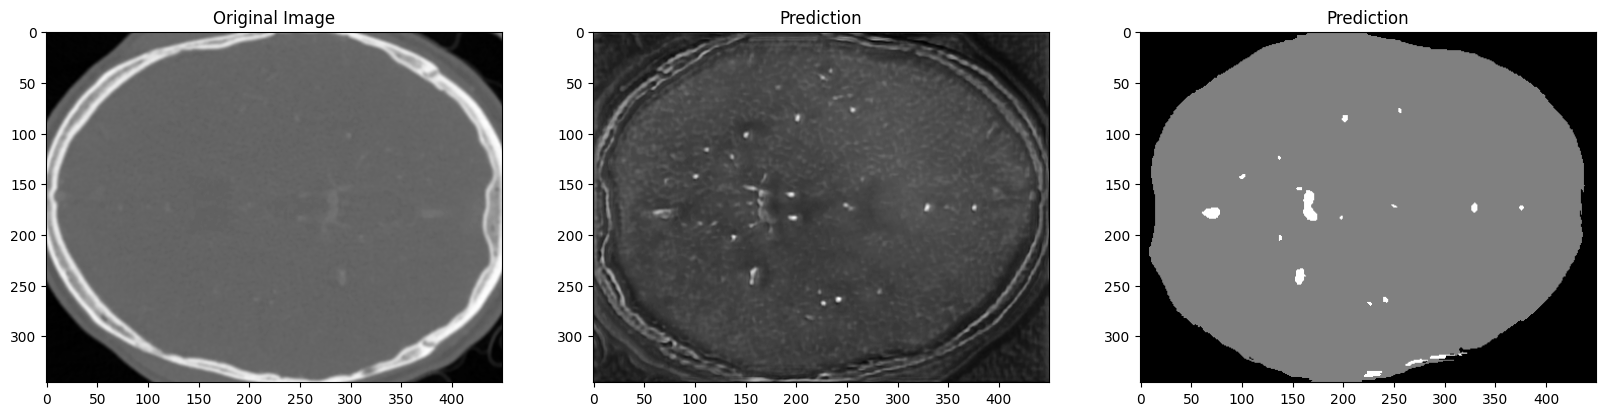

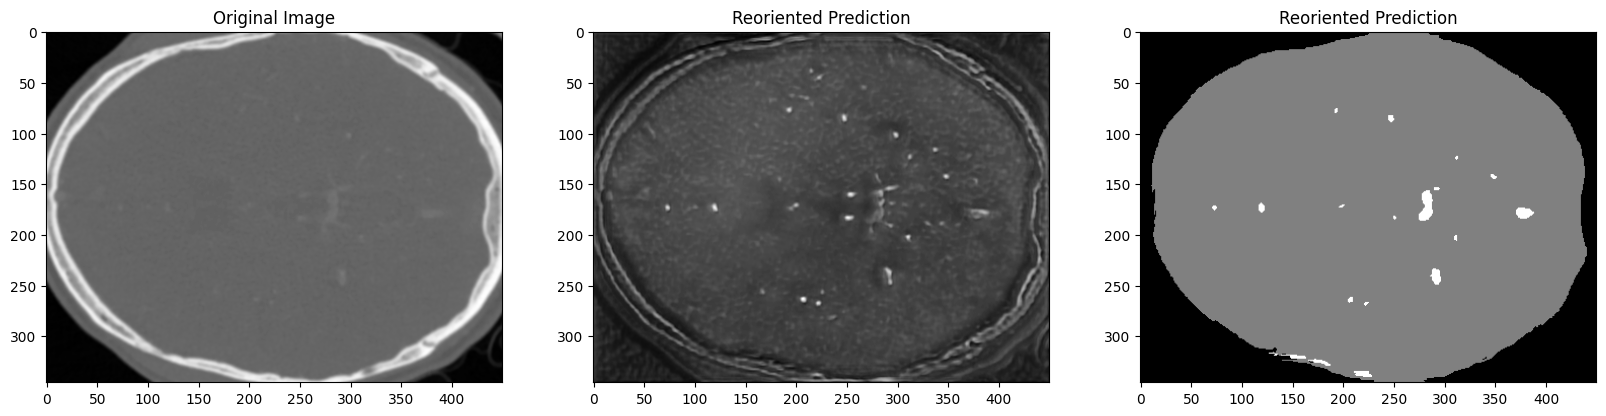

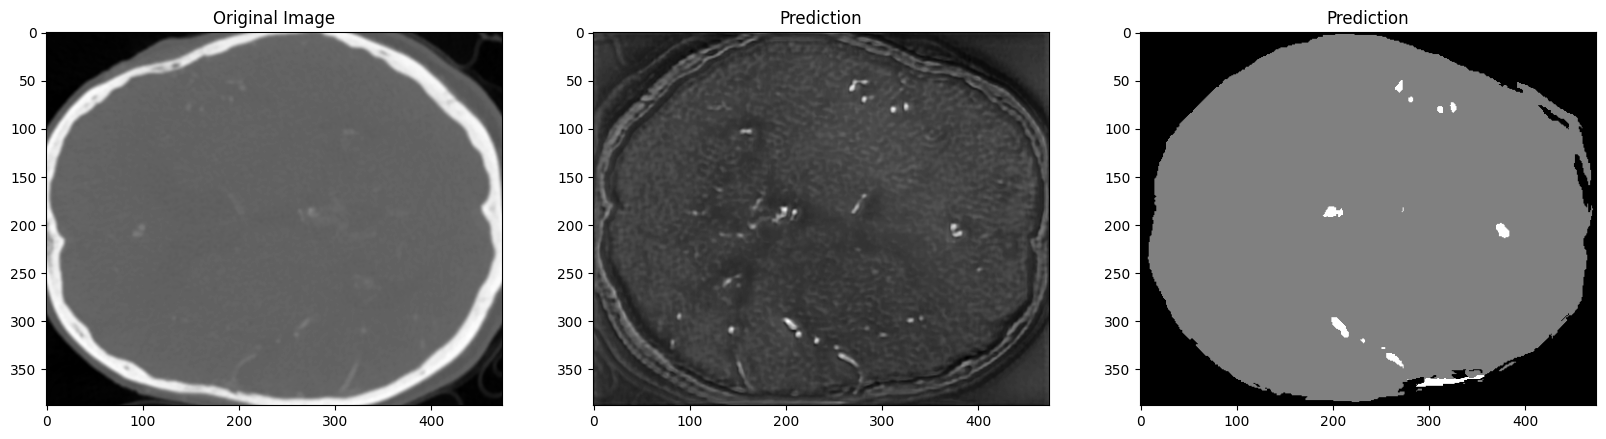

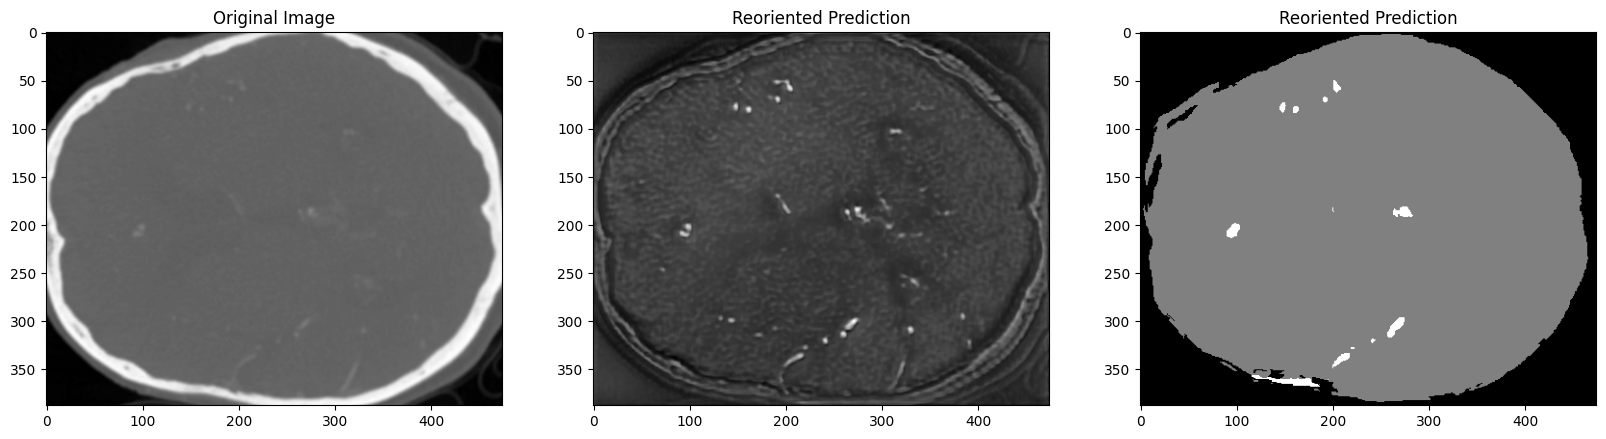

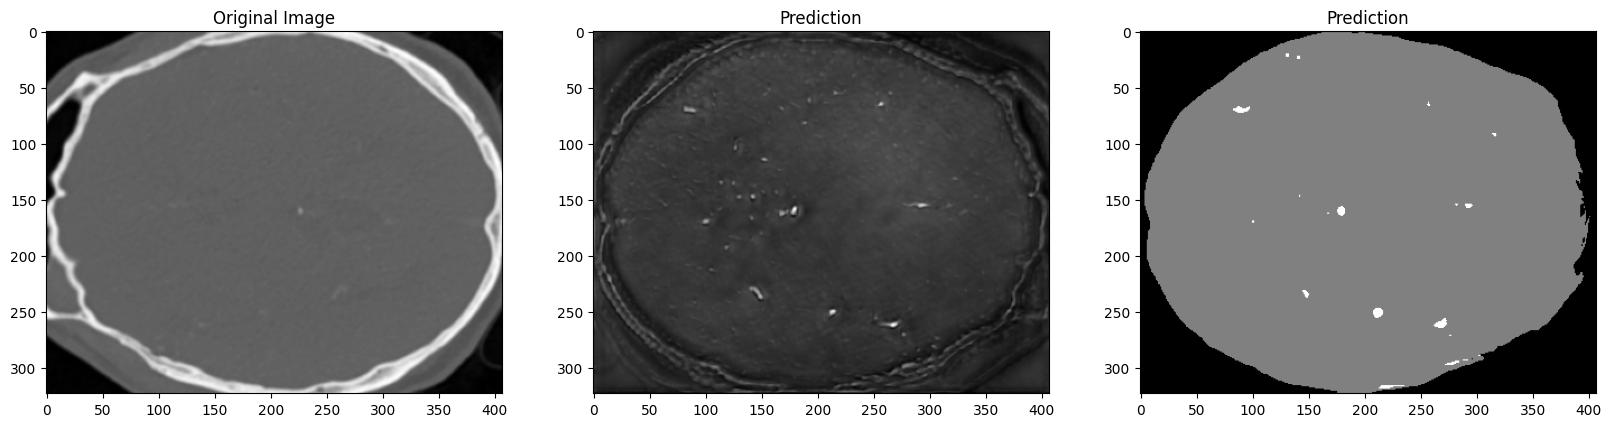

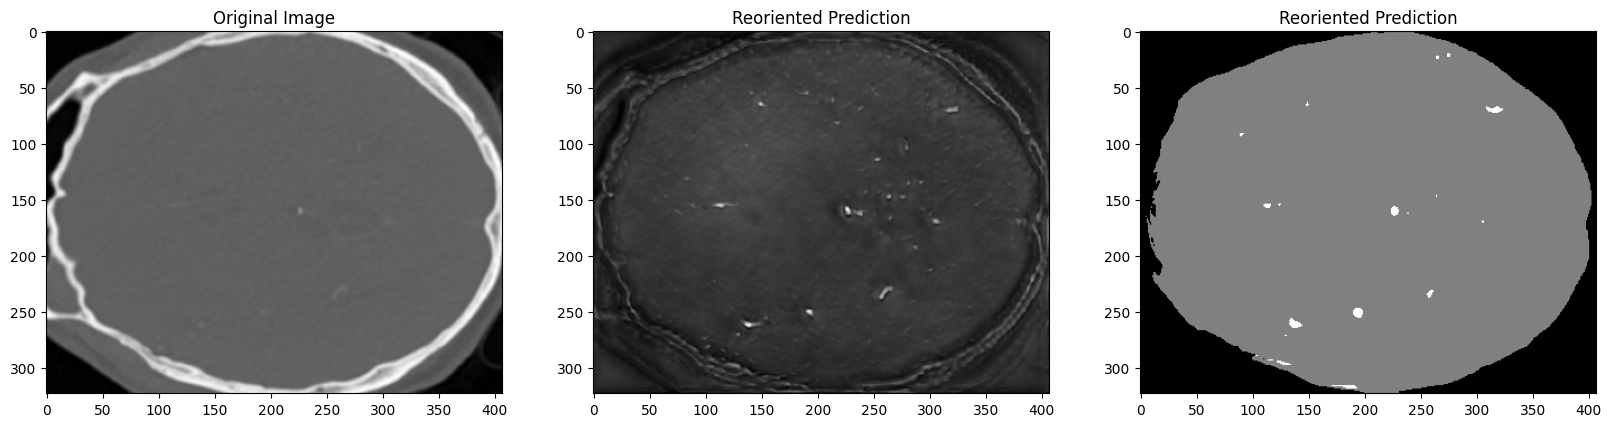

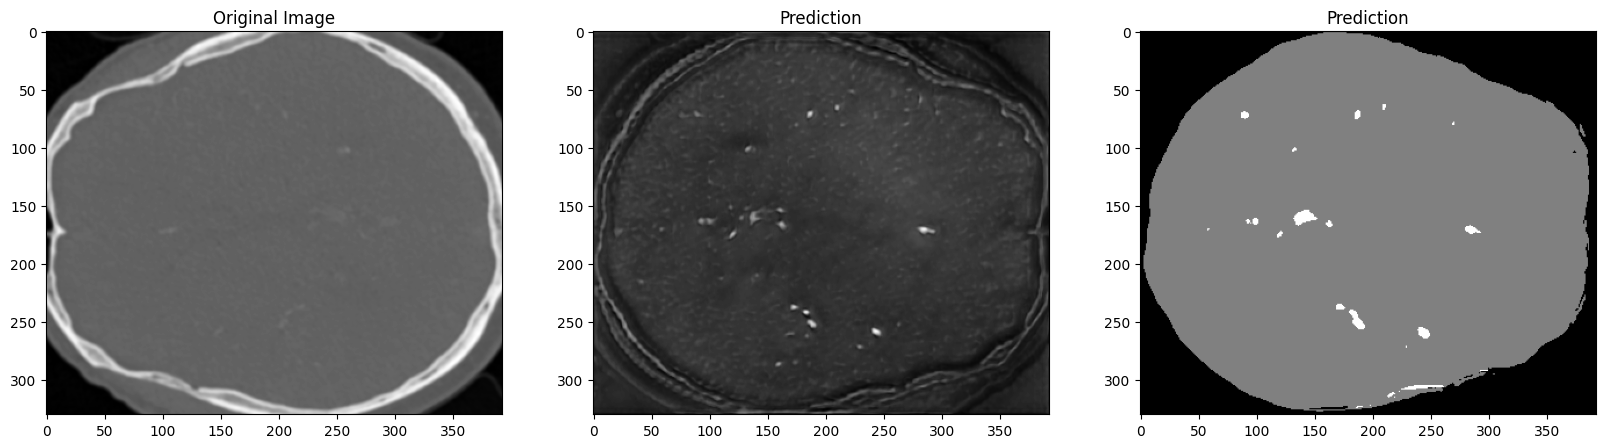

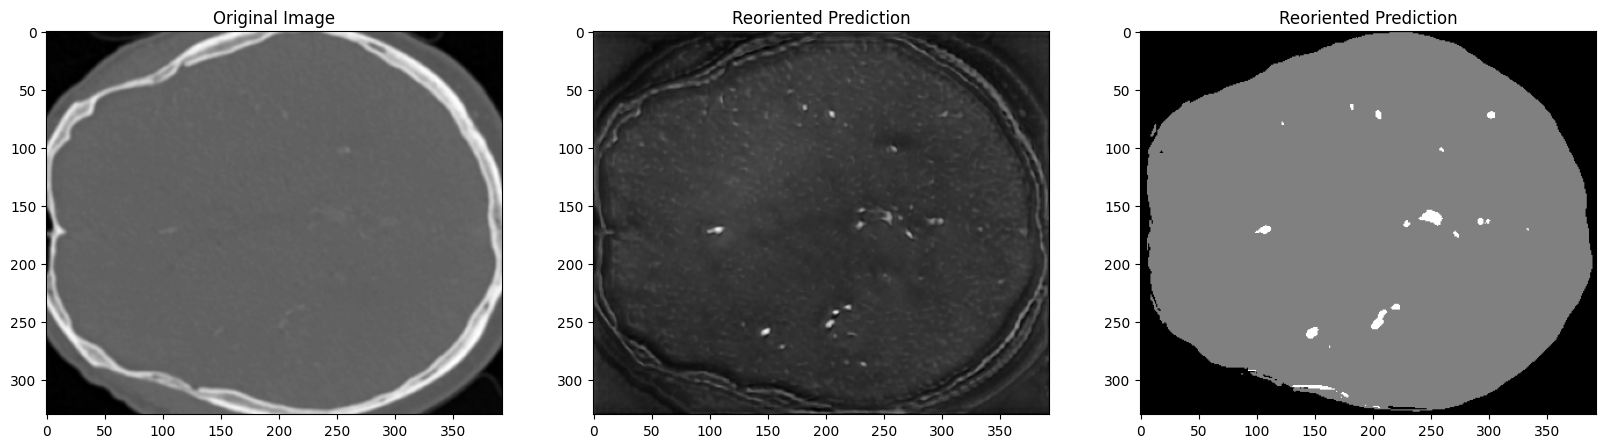

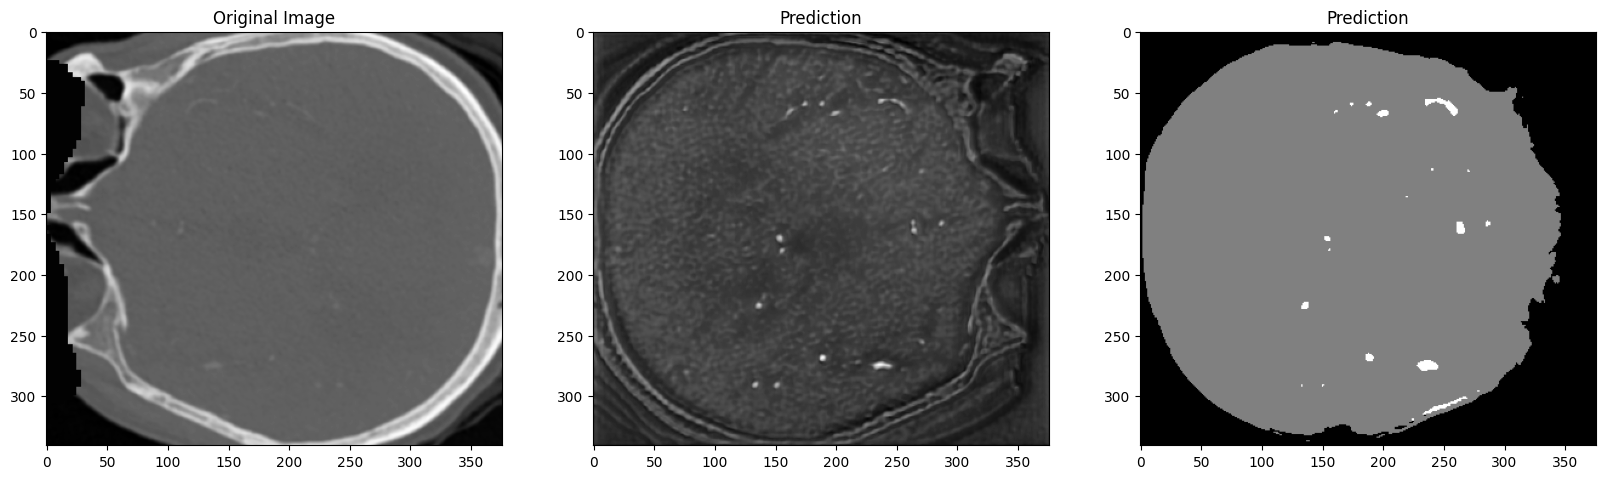

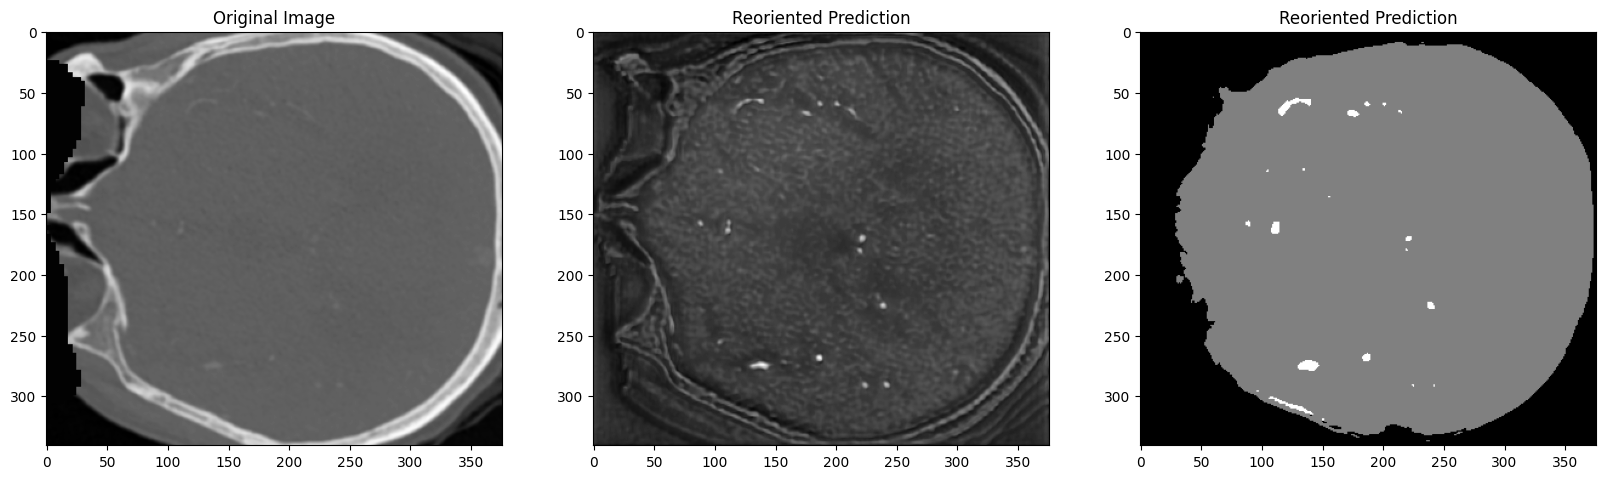

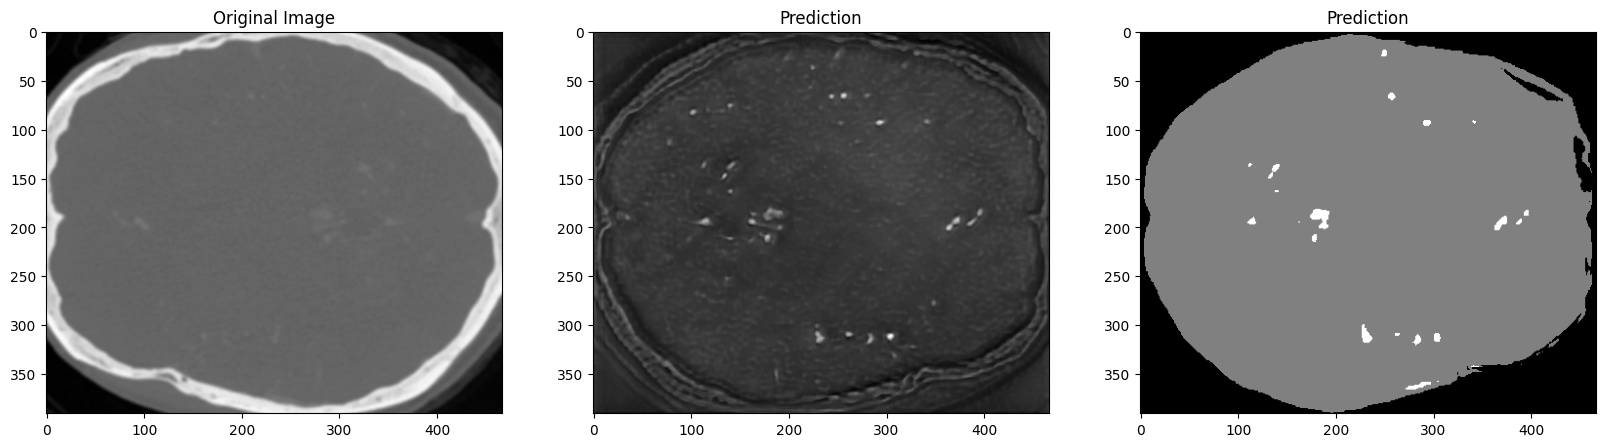

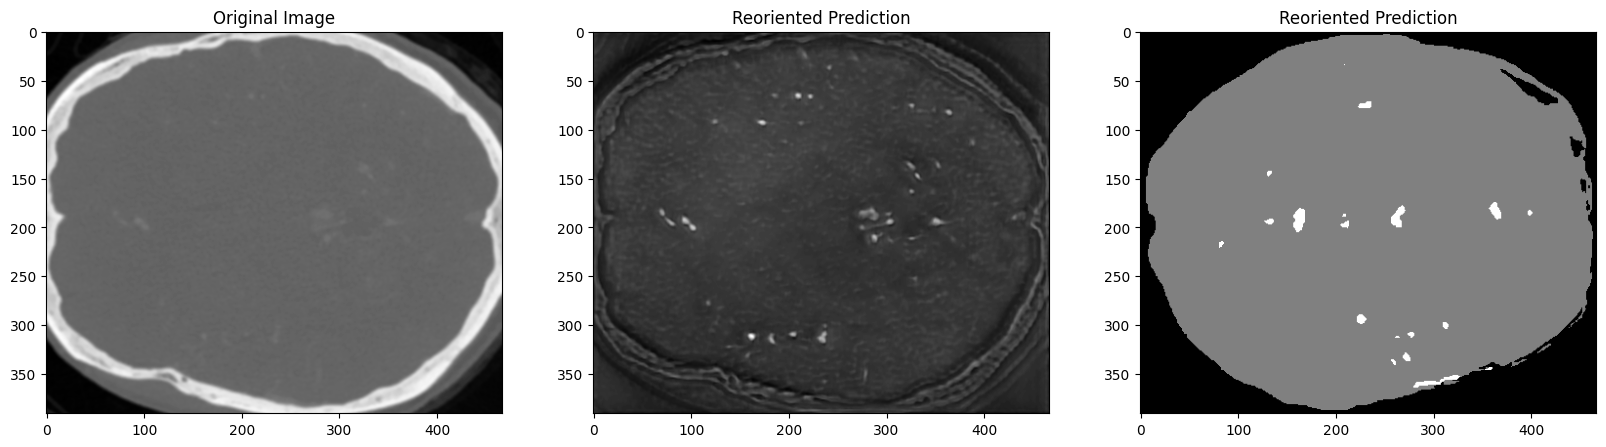

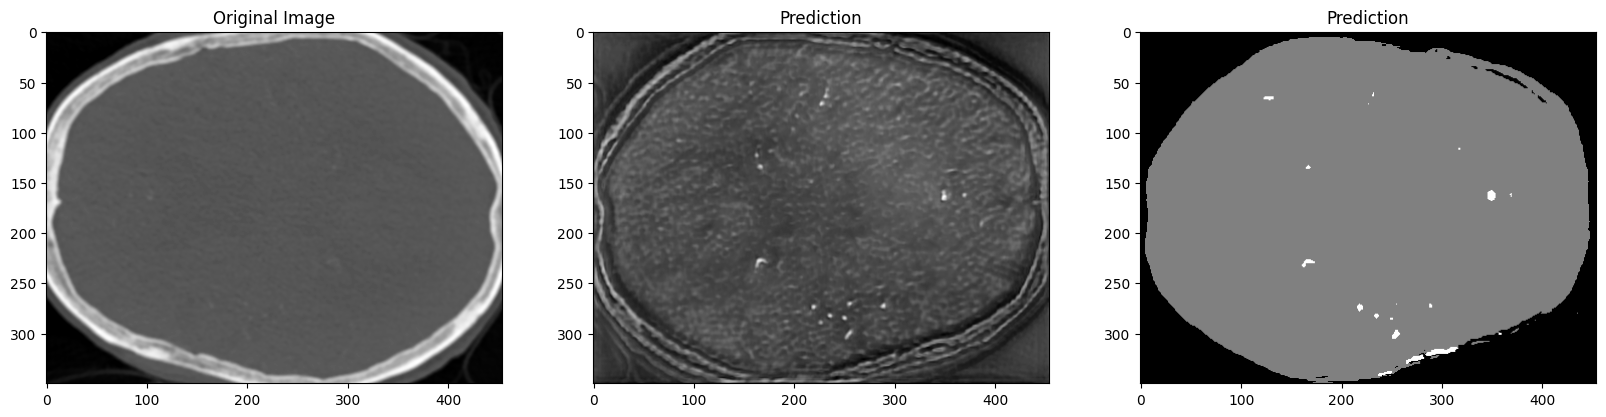

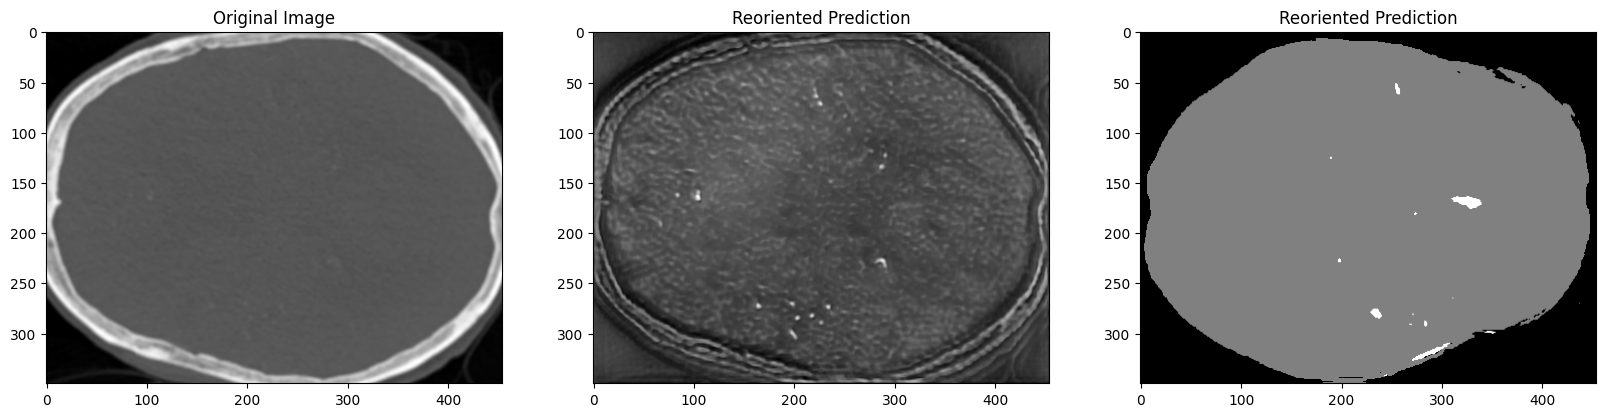

In [88]:
from pathlib import Path


path_pred = '/data/falcetta/A2V_experiments/OUTPUT_phase2/TopCow_INFERENCE'
path_original_imgs = '/data/galati/brain_data/TopCoW_Data_MICCAI2023/topcow_batch-TOT/imagesTr'


for original_img in sorted(os.listdir(path_original_imgs)):
    if 'ct_whole' not in original_img:
        continue
    img_path = os.path.join(path_original_imgs, original_img)
    brain_path = img_path_to_brain_path(img_path)
    vessel_path = img_path_to_vessel_path(img_path)
    vessel_path_complete = img_path_to_vessel_path_complete(img_path)
    assert os.path.exists(img_path), img_path
    assert os.path.exists(brain_path), brain_path
    assert os.path.exists(vessel_path), vessel_path
    
    if '_022_' in original_img:
        print("COMPLETE VESSEL MASK")
        assert os.path.exists(vessel_path_complete), vessel_path_complete
    
    pred_path = os.path.join(path_pred, img_name_to_pred_name(original_img))
    trans_img_path = os.path.join(path_pred, img_name_to_trans_name(original_img))
    inter_img_path = os.path.join(path_pred, img_name_to_inter_name(original_img))
    intra_img_path = os.path.join(path_pred, img_name_to_intra_name(original_img))
    
    
    if not os.path.exists(pred_path):
        print("Missing", pred_path)
        continue
    else:
        assert os.path.exists(pred_path), pred_path
        assert os.path.exists(trans_img_path), trans_img_path
        assert os.path.exists(inter_img_path), inter_img_path
        assert os.path.exists(intra_img_path), intra_img_path
        print("\nProcessing", original_img)
        print(f"Found IMG,TRANS,INTER,INTRA, PRED")

    # LOAD
    img = nib.load(img_path)
    img_np = img.get_fdata()
    
    trs = nib.load(trans_img_path)
    trs_np = trs.get_fdata()
    
    inter = nib.load(inter_img_path)
    inter_np = inter.get_fdata()
    
    intra = nib.load(intra_img_path)
    intra_np = intra.get_fdata()
    
    pred = nib.load(pred_path)
    pred_np = pred.get_fdata()
    
    # Print shapes
    print("Original image shape:", img_np.shape)
    print("Transformed image shape:", trs_np.shape)
    print("Prediction shape:", pred_np.shape)
    
    # Print orientation
    print("Original image orientation:", nib.aff2axcodes(img.affine))
    print("Transformed image orientation:", nib.aff2axcodes(trs.affine))
    print("Prediction orientation:", nib.aff2axcodes(pred.affine))
    
    # Print original spacings
    print("Original image spacing:", img.header.get_zooms()[:3])
    print("Transformed image spacing:", trs.header.get_zooms()[:3])
    print("Prediction spacing:", pred.header.get_zooms()[:3])
    
    slice_ID = 100
    # PLOT
    fig, ax = plt.subplots(1, 3, figsize=(20, 10))
    ax[0].imshow(img_np[:, :, slice_ID], cmap='gray')
    ax[0].set_title("Original Image")
    ax[1].imshow(trs_np[:, :, slice_ID], cmap='gray')
    ax[1].set_title("Prediction")
    ax[2].imshow(pred_np[:, :, slice_ID], cmap='gray')
    ax[2].set_title("Prediction")
    

    reoriented_trs = reorient_with_auto_flip(trs, img)
    reoriented_pred = reorient_with_auto_flip(pred, img)
    reoriented_inter = reorient_with_auto_flip(inter, img)
    reoriented_intra = reorient_with_auto_flip(intra, img)
    
    trs_np = reoriented_trs.get_fdata()
    pred_np = reoriented_pred.get_fdata()
    
    
    # Verify the new orientation matches
    print("Original image orientation:", nib.aff2axcodes(img.affine))
    print("Reoriented image orientation:", nib.aff2axcodes(reoriented_trs.affine))
    print("Reoriented prediction orientation:", nib.aff2axcodes(reoriented_pred.affine))
    
    # Verify new shapes
    print("Original image shape:", img_np.shape)
    print("Resampled transformed shape:", trs_np.shape)
    print("Resampled prediction shape:", pred_np.shape)
    
    fig, ax = plt.subplots(1, 3, figsize=(20, 10))
    
    ax[0].imshow(img_np[:, :, slice_ID], cmap='gray')
    ax[0].set_title("Original Image")
    ax[1].imshow(trs_np[:, :, slice_ID], cmap='gray')
    ax[1].set_title("Reoriented Prediction")
    ax[2].imshow(pred_np[:, :, slice_ID], cmap='gray')
    ax[2].set_title("Reoriented Prediction")
    
    # Check unique values in pred
    print("Unique values in prediction:", np.unique(pred_np))
    unique_values = np.unique(pred_np)
    # Change all the second class to 0
    pred_np[pred_np == unique_values[1]] = unique_values[0]
    # Change all the third class to 1
    pred_np[pred_np == unique_values[2]] = unique_values[1]
    print("Unique values in prediction:", np.unique(pred_np))
    # Save pred_np as a nifti
    
    
    # Save (in the same path as the trans and pred)
    save_oriented_path = os.path.dirname(pred_path).replace('INFERENCE', 'INFERENCE_oriented')
    print(f" Saving reoriented images to {save_oriented_path}")
    Path(save_oriented_path).mkdir(parents=True, exist_ok=True)
    nib.save(reoriented_pred, os.path.join(save_oriented_path, os.path.basename(pred_path)))
    nib.save(reoriented_trs, os.path.join(save_oriented_path, os.path.basename(trans_img_path)))
    nib.save(reoriented_inter, os.path.join(save_oriented_path, os.path.basename(inter_img_path)))
    nib.save(reoriented_intra, os.path.join(save_oriented_path, os.path.basename(intra_img_path)))
    
    nib.save(nib.Nifti1Image(pred_np, reoriented_pred.affine), os.path.join(save_oriented_path, os.path.basename(pred_path).replace(".nii.gz", "_VESSEL.nii.gz")))
 

In [2]:
path = '/data/falcetta/A2V_experiments/TOPCOW_preprocessed/preprocess_TopCow_all/train/unlabeled'

print(f"Number of files in {path}: {len(os.listdir(path))}")

for file in os.listdir(path):
    if file.endswith('.npy') and random.random() < 0.01 and '022' in file:
        print(file)
        array = np.load(os.path.join(path, file), allow_pickle=True).item()
        fig, ax = plt.subplots(1, 4, figsize=(10, 5))
        for i, key in enumerate(array.keys()):
            if key in ['data', 'mask']:
                if key=='mask':
                    for j in range(3):
                        ax[i+j].imshow(array[key][:, :, j])
                    
                ax[i].imshow(array[key][:, :, 0])


Number of files in /data/falcetta/A2V_experiments/TOPCOW_preprocessed/preprocess_TopCow_all/train/unlabeled: 13441
